In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
sys.path.insert(0, ".")
from loader import load_data
from preprocessor import preprocess, get_train_test

/Users/harsha/Desktop/FlowSense/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df          = load_data()
df          = preprocess(df)
train, test = get_train_test(df)

Loaded 731 rows | 2023-01-01 → 2024-12-31
Preprocessed | shape=(731, 22) | new cols added: 15
Train: 639 rows | Test: 92 rows | split=2024-09-30


In [4]:
FEATURES = [
    "year", "month_num", "day_of_month", "week_of_year",
    "quarter", "dow_num", "is_weekend", "is_month_start",
    "is_month_end", "days_to_gst", "is_festival",
    "is_market_drop", "gst_filing_flag",
    "lag_1", "lag_7", "lag_30",
    "rolling_7_mean", "rolling_30_mean"
]

X_train = train[FEATURES]
y_train = train["y"]
X_test  = test[FEATURES]
y_test  = test["y"]

In [5]:
model = LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)
print("LightGBM model trained!")

LightGBM model trained!


In [6]:
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test.values - preds) / y_test.values)) * 100

print("── Model Performance ──────────────────")
print(f"  MAE  : ₹{mae:,.0f}")
print(f"  RMSE : ₹{rmse:,.0f}")
print(f"  MAPE : {mape:.2f}%")

── Model Performance ──────────────────
  MAE  : ₹20,269
  RMSE : ₹29,088
  MAPE : 31.47%


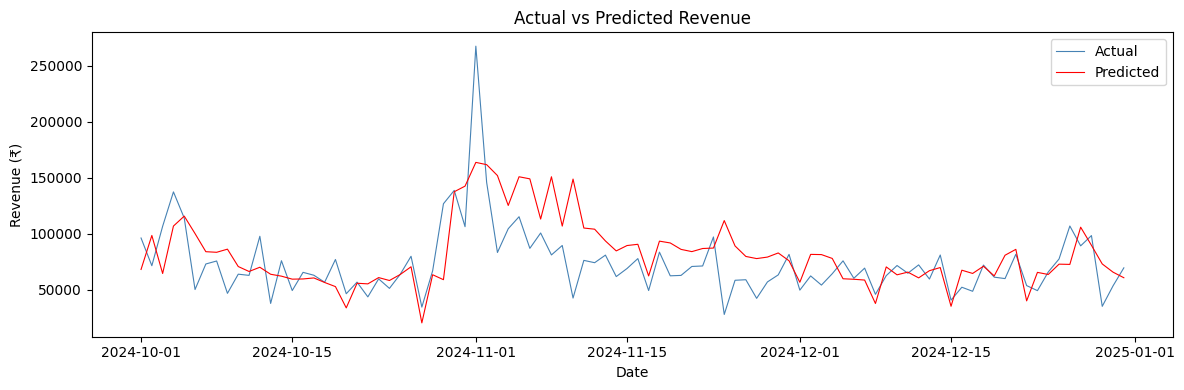

In [7]:
test = test.copy()
test["predicted"] = preds.astype(int)
test[["ds", "y", "predicted"]].to_csv("01_test_predictions.csv", index=False)

plt.figure(figsize=(12, 4))
plt.plot(test["ds"], test["y"],         color="steelblue", linewidth=0.8, label="Actual")
plt.plot(test["ds"], test["predicted"], color="red",       linewidth=0.8, label="Predicted")
plt.xlabel("Date"); plt.ylabel("Revenue (₹)"); plt.title("Actual vs Predicted Revenue")
plt.legend(); plt.tight_layout()
plt.savefig("01_test_predictions.png"); plt.show()

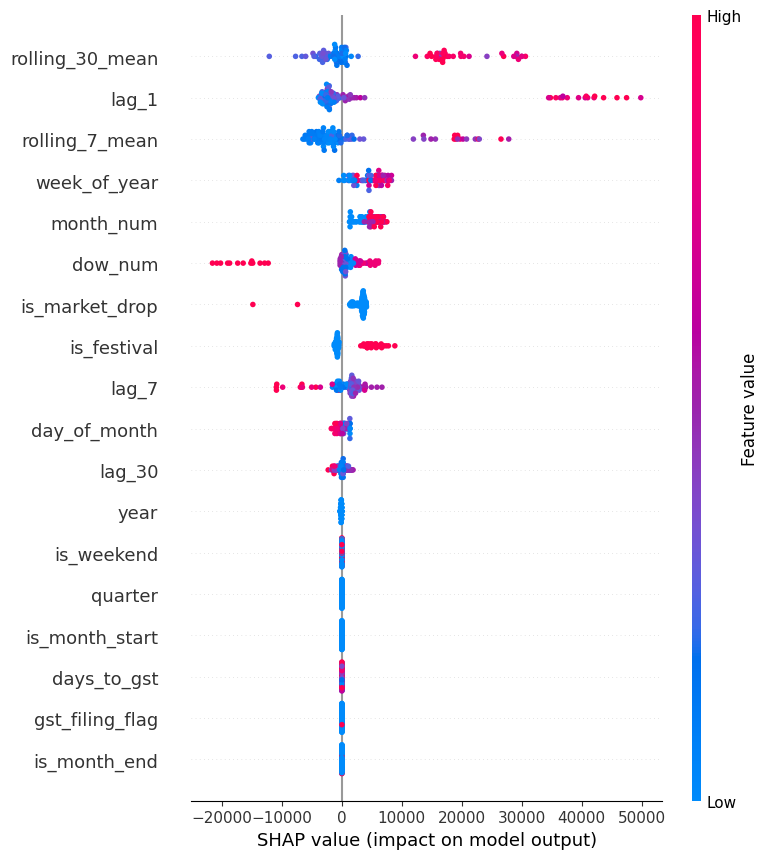

Saved 03_shap_summary.png


In [8]:
explainer   = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout(); plt.savefig("03_shap_summary.png"); plt.show()
print("Saved 03_shap_summary.png")

In [9]:
last_date    = df["ds"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=90)
future = pd.DataFrame({"ds": future_dates})
future["year"]           = future["ds"].dt.year
future["month_num"]      = future["ds"].dt.month
future["day_of_month"]   = future["ds"].dt.day
future["week_of_year"]   = future["ds"].dt.isocalendar().week.astype(int)
future["quarter"]        = future["ds"].dt.quarter
future["dow_num"]        = future["ds"].dt.dayofweek
future["is_weekend"]     = (future["dow_num"] >= 5).astype(int)
future["is_month_start"] = future["ds"].dt.is_month_start.astype(int)
future["is_month_end"]   = future["ds"].dt.is_month_end.astype(int)
future["days_to_gst"]    = (20 - future["day_of_month"]).clip(-10, 10)
future["is_festival"]    = 0
future["is_market_drop"] = 0
future["gst_filing_flag"]= (future["day_of_month"] == 20).astype(int)
future["lag_1"]          = df["y"].iloc[-1]
future["lag_7"]          = df["y"].iloc[-7]
future["lag_30"]         = df["y"].iloc[-30]
future["rolling_7_mean"] = df["y"].iloc[-7:].mean()
future["rolling_30_mean"]= df["y"].iloc[-30:].mean()
future["predicted"] = model.predict(future[FEATURES]).astype(int)
future[["ds", "predicted"]].to_csv("02_future_forecast.csv", index=False)
print("Saved 02_future_forecast.csv")

Saved 02_future_forecast.csv


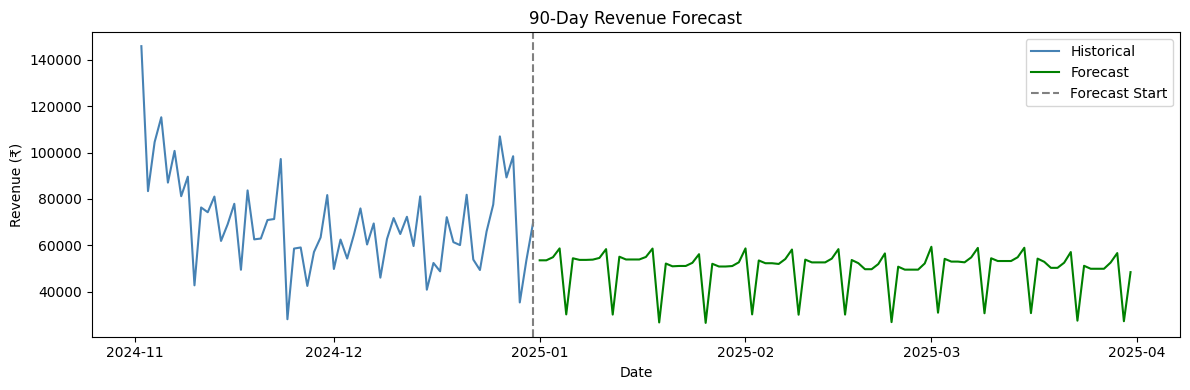

All done!


In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df["ds"].iloc[-60:], df["y"].iloc[-60:], color="steelblue", label="Historical")
plt.plot(future["ds"], future["predicted"],        color="green",     label="Forecast")
plt.axvline(last_date, color="gray", linestyle="--", label="Forecast Start")
plt.xlabel("Date"); plt.ylabel("Revenue (₹)"); plt.title("90-Day Revenue Forecast")
plt.legend(); plt.tight_layout()
plt.savefig("02_future_forecast.png"); plt.show()
print("All done!")

In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

FEATURES = [
    "year", "month_num", "day_of_month", "week_of_year",
    "quarter", "dow_num", "is_weekend", "is_month_start",
    "is_month_end", "days_to_gst", "is_festival",
    "is_market_drop", "gst_filing_flag",
    "lag_1", "lag_7", "lag_30",
    "rolling_7_mean", "rolling_30_mean"
]

X = df[FEATURES]
y = df["y"]

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    m = LGBMRegressor(n_estimators=200, max_depth=6, 
                      learning_rate=0.05, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr)
    preds = m.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)
    print(f"Fold {fold+1} MAE: Rs.{mae:,.0f}")

print(f"\nAverage MAE across 5 folds: Rs.{np.mean(mae_scores):,.0f}")
print(f"Std Dev: Rs.{np.std(mae_scores):,.0f}")

Fold 1 MAE: Rs.10,999
Fold 2 MAE: Rs.20,864
Fold 3 MAE: Rs.8,540
Fold 4 MAE: Rs.5,991
Fold 5 MAE: Rs.17,679

Average MAE across 5 folds: Rs.12,815
Std Dev: Rs.5,596
